# CMS Open Data: exploratory $J/\psi \rightarrow e^+e^-$ peak check

This notebook performs a lightweight diagnostic check for a visible $J/\psi \rightarrow e^+e^-$ candidate peak in the reduced CMS DoubleElectron NanoAOD file used by the existing $Z \rightarrow e^+e^-$ study. It intentionally uses loose low-$p_T$ electron selections and raw opposite-sign pair counts.

In [35]:
from pathlib import Path

import numpy as np
import awkward as ak
import uproot
import vector
import matplotlib.pyplot as plt

vector.register_awkward()

In [36]:
# J/psi-oriented loose electron selection
# The Z->ee notebook uses pT > 20 GeV, which removes nearly all J/psi candidates.
electron_pt_min = 2.0
electron_abs_eta_max = 2.5

# Electron quality cuts
electron_iso_max = 0.30
electron_dxy_max = 0.10
electron_dz_max = 0.20

# Retain the Z notebook's ECAL barrel/endcap transition gap veto by default.
remove_ecal_gap = True

# Diagnostic mass windows
broad_mass_min = 2.0
broad_mass_max = 15.0

jpsi_mass_min = 2.6
jpsi_mass_max = 3.5
jpsi_reference_mass = 3.0969

In [37]:
ROOT_FILE_EE = Path("../cms_zpeak/data/Run2012B_DoubleElectron.root")

assert ROOT_FILE_EE.exists(), f"File not found: {ROOT_FILE_EE.resolve()}"

f_ee = uproot.open(ROOT_FILE_EE)
events_ee = f_ee["Events"]

print("File:", ROOT_FILE_EE.resolve())
print("Number of events:", events_ee.num_entries)

electron_branches = [k for k in events_ee.keys() if "Electron" in k]
print("Available electron branches:")
for branch in electron_branches:
    print("  ", branch)

File: /Users/ahrimarin/Desktop/otus_on_data/experiments/cms_zpeak/data/Run2012B_DoubleElectron.root
Number of events: 21474287
Available electron branches:
   nElectron
   Electron_pt
   Electron_eta
   Electron_phi
   Electron_mass
   Electron_charge
   Electron_pfRelIso03_all
   Electron_dxy
   Electron_dxyErr
   Electron_dz
   Electron_dzErr


In [38]:
branches_ee = [
    "nElectron",
    "Electron_pt",
    "Electron_eta",
    "Electron_phi",
    "Electron_mass",
    "Electron_charge",
    "Electron_pfRelIso03_all",
    "Electron_dxy",
    "Electron_dxyErr",
    "Electron_dz",
    "Electron_dzErr",
]

arrays_ee = events_ee.arrays(branches_ee, library="ak")

print("Loaded events:", len(arrays_ee["nElectron"]))
print("Example nElectron values:", arrays_ee["nElectron"][:10])

Loaded events: 21474287
Example nElectron values: [0, 1, 2, 2, 1, 2, 0, 2, 1, 0]


In [39]:
# Build electron Lorentz-vector objects
electrons = ak.zip(
    {
        "pt": arrays_ee["Electron_pt"],
        "eta": arrays_ee["Electron_eta"],
        "phi": arrays_ee["Electron_phi"],
        "mass": arrays_ee["Electron_mass"],
        "charge": arrays_ee["Electron_charge"],
        "pfRelIso03_all": arrays_ee["Electron_pfRelIso03_all"],
        "dxy": arrays_ee["Electron_dxy"],
        "dxyErr": arrays_ee["Electron_dxyErr"],
        "dz": arrays_ee["Electron_dz"],
        "dzErr": arrays_ee["Electron_dzErr"],
    },
    with_name="Momentum4D",
)

def select_electrons(pt_min):
    abs_eta = np.abs(electrons.eta)

    if remove_ecal_gap:
        # ECAL barrel/endcap transition gap veto used by the Z->ee notebook.
        outside_ecal_gap = ~((abs_eta > 1.4442) & (abs_eta < 1.566))
    else:
        outside_ecal_gap = ak.ones_like(electrons.pt, dtype=bool)

    return electrons[
        (electrons.pt > pt_min)
        & (abs_eta < electron_abs_eta_max)
        & outside_ecal_gap
        & (electrons.pfRelIso03_all < electron_iso_max)
        & (np.abs(electrons.dxy) < electron_dxy_max)
        & (np.abs(electrons.dz) < electron_dz_max)
    ]

def build_pairs_and_masses(electron_collection, sign="opposite"):
    pairs = ak.combinations(
        electron_collection,
        2,
        fields=["e1", "e2"],
    )

    charge_product = pairs.e1.charge * pairs.e2.charge
    if sign == "opposite":
        selected_pairs = pairs[charge_product < 0]
    elif sign == "same":
        selected_pairs = pairs[charge_product > 0]
    else:
        raise ValueError(f"Unknown sign selection: {sign}")

    masses = (selected_pairs.e1 + selected_pairs.e2).mass
    return selected_pairs, ak.to_numpy(ak.flatten(masses))

selected_electrons = select_electrons(electron_pt_min)
os_pairs_ee, masses_ee = build_pairs_and_masses(selected_electrons, sign="opposite")
ss_pairs_ee, masses_ee_same_sign = build_pairs_and_masses(selected_electrons, sign="same")

masses_ee_broad = masses_ee[
    (masses_ee > broad_mass_min)
    & (masses_ee < broad_mass_max)
]

masses_ee_jpsi = masses_ee[
    (masses_ee > jpsi_mass_min)
    & (masses_ee < jpsi_mass_max)
]

masses_ee_same_sign_jpsi = masses_ee_same_sign[
    (masses_ee_same_sign > jpsi_mass_min)
    & (masses_ee_same_sign < jpsi_mass_max)
]

print("Total selected electrons:", ak.sum(ak.num(selected_electrons)))
print("Events with >=2 selected electrons:", ak.sum(ak.num(selected_electrons) >= 2))
print("Opposite-sign dielectron pairs:", ak.sum(ak.num(os_pairs_ee)))
print(f"Opposite-sign pairs in {broad_mass_min:g}-{broad_mass_max:g} GeV:", len(masses_ee_broad))
print(f"Opposite-sign pairs in {jpsi_mass_min:g}-{jpsi_mass_max:g} GeV:", len(masses_ee_jpsi))
print(f"Same-sign pairs in {jpsi_mass_min:g}-{jpsi_mass_max:g} GeV:", len(masses_ee_same_sign_jpsi))

Total selected electrons: 16086164
Events with >=2 selected electrons: 4082727
Opposite-sign dielectron pairs: 3470072
Opposite-sign pairs in 2-15 GeV: 202938
Opposite-sign pairs in 2.6-3.5 GeV: 25213
Same-sign pairs in 2.6-3.5 GeV: 18055


Broad-spectrum bin width = 0.050 GeV


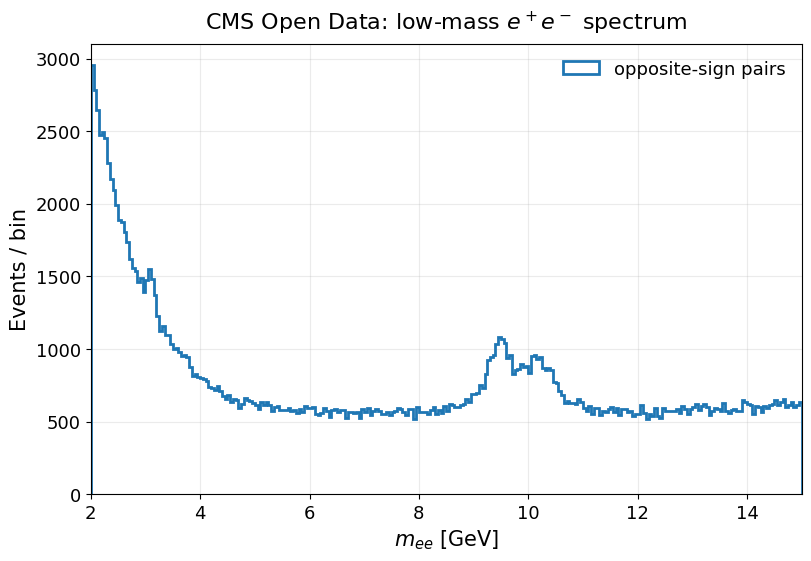

In [40]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins_broad = np.linspace(2.0, 15.0, 261)
bin_width_broad = bins_broad[1] - bins_broad[0]

ax.hist(
    masses_ee_broad,
    bins=bins_broad,
    histtype="step",
    linewidth=2,
    label="opposite-sign pairs",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel("Events / bin", fontsize=15)
ax.set_xlim(broad_mass_min, broad_mass_max)
ax.tick_params(axis="both", labelsize=13)
ax.grid(alpha=0.25)

ax.set_title(r"CMS Open Data: low-mass $e^+e^-$ spectrum", fontsize=16, pad=10)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=13,
)


print(f"Broad-spectrum bin width = {bin_width_broad:.3f} GeV")

J/psi-zoom bin width = 0.0050 GeV
Highest-bin peak center = 2.6125 GeV
Highest-bin count = 200


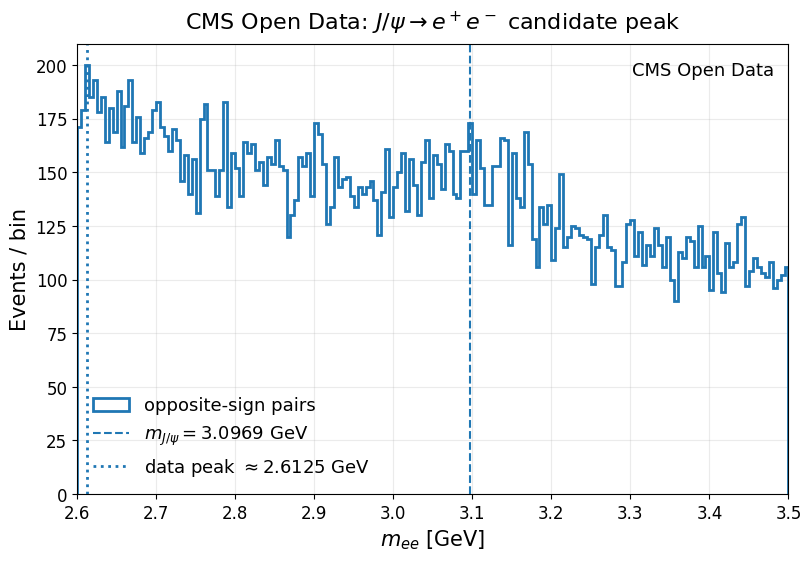

In [41]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins_jpsi = np.linspace(2.6, 3.5, 181)
bin_width_jpsi = bins_jpsi[1] - bins_jpsi[0]

counts_jpsi, edges_jpsi = np.histogram(masses_ee_jpsi, bins=bins_jpsi)
centers_jpsi = 0.5 * (edges_jpsi[:-1] + edges_jpsi[1:])
peak_mass_jpsi = centers_jpsi[np.argmax(counts_jpsi)] if len(counts_jpsi) else np.nan
peak_count_jpsi = np.max(counts_jpsi) if len(counts_jpsi) else 0

ax.hist(
    masses_ee_jpsi,
    bins=bins_jpsi,
    histtype="step",
    linewidth=2,
    label="opposite-sign pairs",
)

ax.axvline(
    jpsi_reference_mass,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_{J/\psi} = 3.0969$ GeV",
)

ax.axvline(
    peak_mass_jpsi,
    linestyle=":",
    linewidth=2.0,
    label=fr"data peak $\approx {peak_mass_jpsi:.4f}$ GeV",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel("Events / bin", fontsize=15)
ax.set_xlim(jpsi_mass_min, jpsi_mass_max)
ax.tick_params(axis="both", labelsize=12)
ax.grid(alpha=0.25)

ax.set_title(r"CMS Open Data: $J/\psi \rightarrow e^+e^-$ candidate peak", fontsize=16, pad=10)

ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

print(f"J/psi-zoom bin width = {bin_width_jpsi:.4f} GeV")
print(f"Highest-bin peak center = {peak_mass_jpsi:.4f} GeV")
print(f"Highest-bin count = {peak_count_jpsi}")

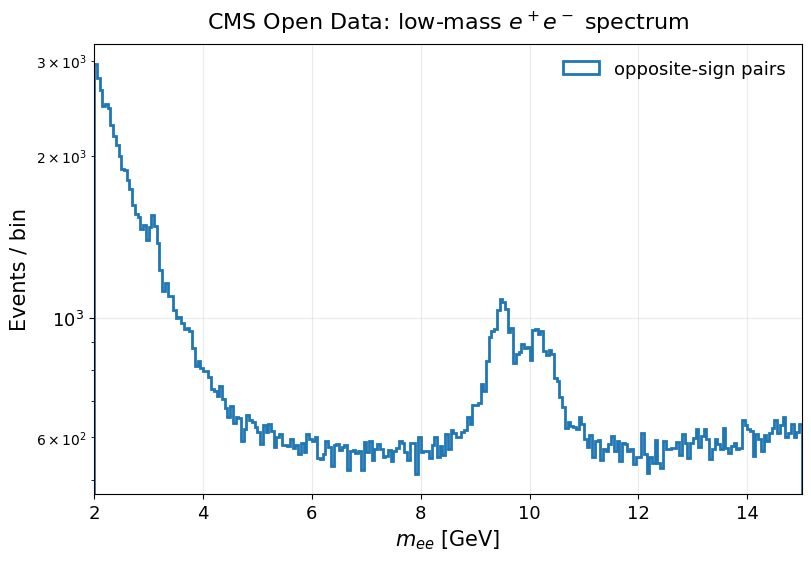

In [42]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

ax.hist(
    masses_ee_broad,
    bins=bins_broad,
    histtype="step",
    linewidth=2,
    label="opposite-sign pairs",
)

ax.set_yscale("log")
ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel("Events / bin", fontsize=15)
ax.set_xlim(broad_mass_min, broad_mass_max)
ax.tick_params(axis="both", labelsize=13)
ax.grid(alpha=0.25)

ax.set_title(r"CMS Open Data: low-mass $e^+e^-$ spectrum", fontsize=16, pad=10)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=13,
)


pT > 2 GeV: 25213 OS pairs in 2.6-3.5 GeV
pT > 3 GeV: 25213 OS pairs in 2.6-3.5 GeV
pT > 5 GeV: 25213 OS pairs in 2.6-3.5 GeV


Text(0.98, 0.96, 'CMS Open Data')

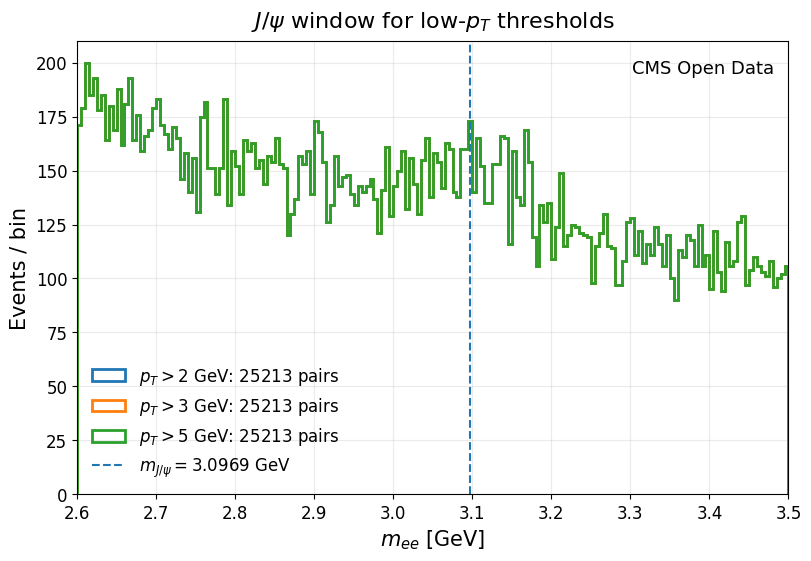

In [43]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

pt_thresholds = [2.0, 3.0, 5.0]
threshold_jpsi_counts = {}
threshold_jpsi_masses = {}

for pt_threshold in pt_thresholds:
    selected_for_threshold = select_electrons(pt_threshold)
    _, masses_for_threshold = build_pairs_and_masses(selected_for_threshold, sign="opposite")
    masses_for_threshold_jpsi = masses_for_threshold[
        (masses_for_threshold > jpsi_mass_min)
        & (masses_for_threshold < jpsi_mass_max)
    ]

    threshold_jpsi_counts[pt_threshold] = len(masses_for_threshold_jpsi)
    threshold_jpsi_masses[pt_threshold] = masses_for_threshold_jpsi

    ax.hist(
        masses_for_threshold_jpsi,
        bins=bins_jpsi,
        histtype="step",
        linewidth=2,
        label=fr"$p_T > {pt_threshold:.0f}$ GeV: {len(masses_for_threshold_jpsi)} pairs",
    )

    print(f"pT > {pt_threshold:.0f} GeV: {len(masses_for_threshold_jpsi)} OS pairs in {jpsi_mass_min:g}-{jpsi_mass_max:g} GeV")

ax.axvline(
    jpsi_reference_mass,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_{J/\psi} = 3.0969$ GeV",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel("Events / bin", fontsize=15)
ax.set_xlim(jpsi_mass_min, jpsi_mass_max)
ax.tick_params(axis="both", labelsize=12)
ax.grid(alpha=0.25)

ax.set_title(r"$J/\psi$ window for low-$p_T$ thresholds", fontsize=16, pad=10)

ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=12,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

Text(0.98, 0.96, 'CMS Open Data')

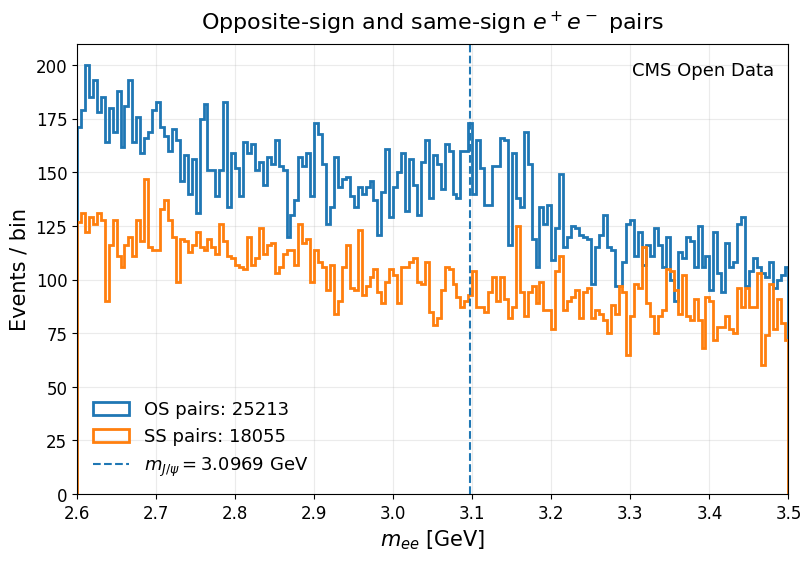

In [44]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

ax.hist(
    masses_ee_jpsi,
    bins=bins_jpsi,
    histtype="step",
    linewidth=2,
    label=f"OS pairs: {len(masses_ee_jpsi)}",
)

ax.hist(
    masses_ee_same_sign_jpsi,
    bins=bins_jpsi,
    histtype="step",
    linewidth=2,
    label=f"SS pairs: {len(masses_ee_same_sign_jpsi)}",
)

ax.axvline(
    jpsi_reference_mass,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_{J/\psi} = 3.0969$ GeV",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel("Events / bin", fontsize=15)
ax.set_xlim(jpsi_mass_min, jpsi_mass_max)
ax.tick_params(axis="both", labelsize=12)
ax.grid(alpha=0.25)

ax.set_title(r"Opposite-sign and same-sign $e^+e^-$ pairs", fontsize=16, pad=10)

ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

In [45]:
def print_mass_summary(label, masses):
    print(label)
    print(f"number of opposite-sign pairs: {len(masses)}")
    if len(masses):
        print(f"mean mass:   {np.mean(masses):.6f} GeV")
        print(f"median mass: {np.median(masses):.6f} GeV")
    else:
        print("mean mass:   n/a")
        print("median mass: n/a")

print_mass_summary(f"Full {broad_mass_min:g}-{broad_mass_max:g} GeV window:", masses_ee_broad)
print()
print_mass_summary(f"J/psi {jpsi_mass_min:g}-{jpsi_mass_max:g} GeV window:", masses_ee_jpsi)
print(f"highest-bin peak position: {peak_mass_jpsi:.6f} GeV")
print()
print("J/psi-window pair counts by electron pT threshold:")
for pt_threshold in pt_thresholds:
    print(f"pT > {pt_threshold:.0f} GeV: {threshold_jpsi_counts[pt_threshold]}")

Full 2-15 GeV window:
number of opposite-sign pairs: 202938
mean mass:   7.410805 GeV
median mass: 7.176325 GeV

J/psi 2.6-3.5 GeV window:
number of opposite-sign pairs: 25213
mean mass:   3.010784 GeV
median mass: 3.000203 GeV
highest-bin peak position: 2.612500 GeV

J/psi-window pair counts by electron pT threshold:
pT > 2 GeV: 25213
pT > 3 GeV: 25213
pT > 5 GeV: 25213
